<a href="https://colab.research.google.com/github/ariba8001-maker/Supervise-Machine-Learning-Model-/blob/main/Decision_Tree%26_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
df = pd.read_csv("/content/Student_Performance.csv")
df

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f


In [ ]:
df.shape

(25000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [ ]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
school_type,0
parent_education,0
study_hours,0
attendance_percentage,0
internet_access,0
travel_time,0
extra_activities,0


In [ ]:
df.drop(columns=["student_id", "study_hours"], inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [ ]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)


{'age': 0, 'attendance_percentage': 0, 'math_score': 10, 'science_score': 12, 'english_score': 2, 'overall_score': 0}


In [ ]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

                  Column  Outlier_Count
3          science_score             12
2             math_score             10
4          english_score              2
0                    age              0
1  attendance_percentage              0
5          overall_score              0


In [ ]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

                  Column  Outlier_Count  Percentage
3          science_score             12       0.048
2             math_score             10       0.040
4          english_score              2       0.008
0                    age              0       0.000
1  attendance_percentage              0       0.000
5          overall_score              0       0.000


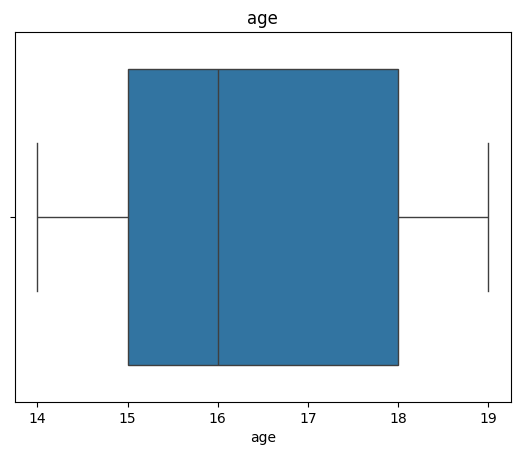

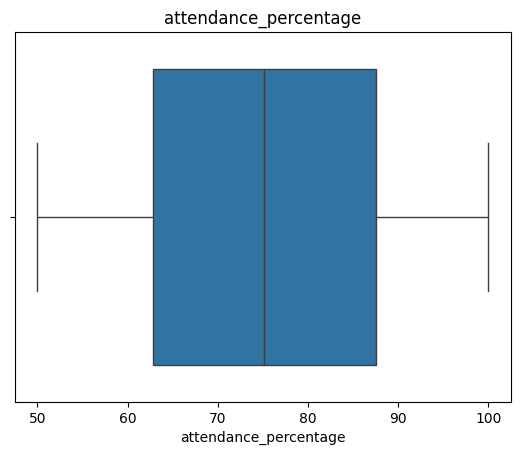

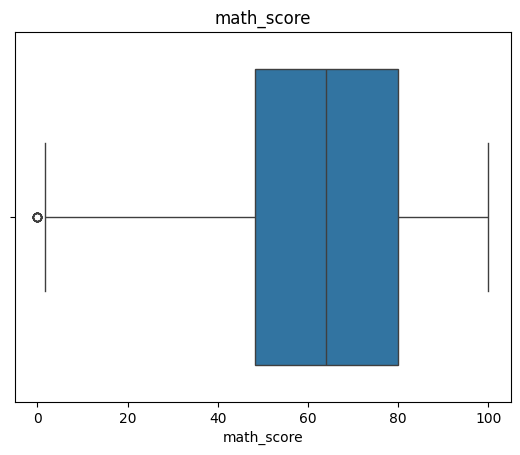

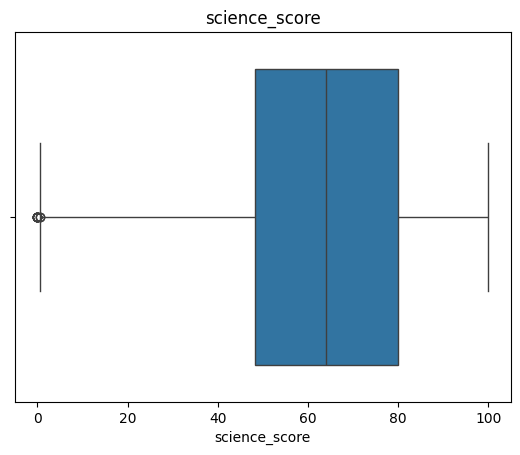

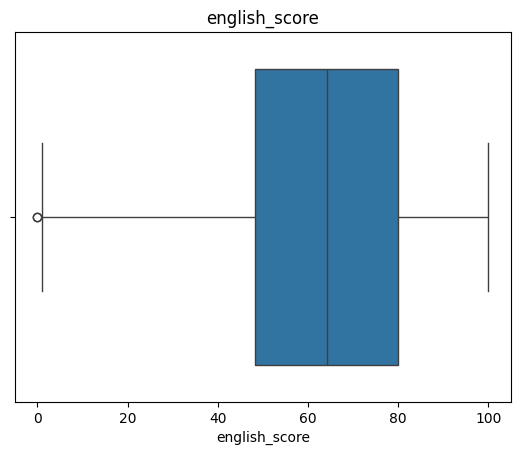

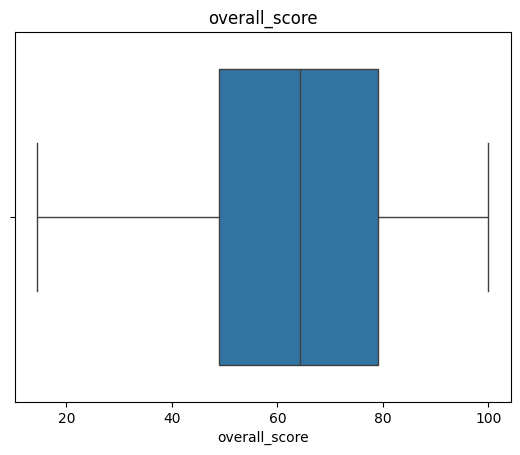

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
cols_to_cap = [
    'math_score',
    'science_score',
    'english_score'
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

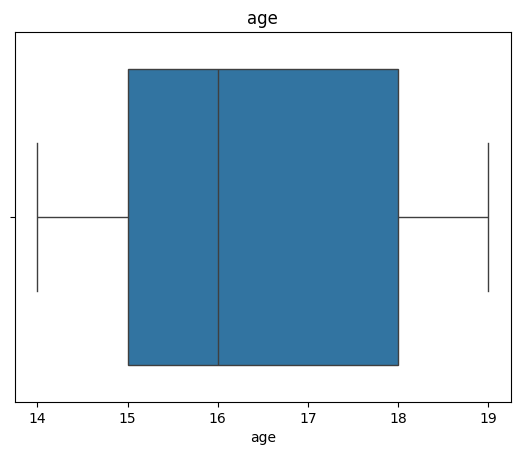

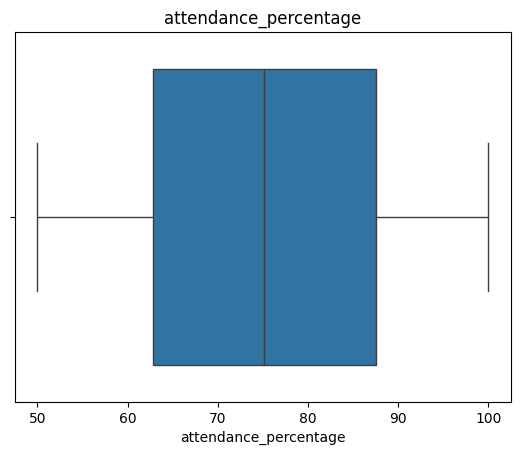

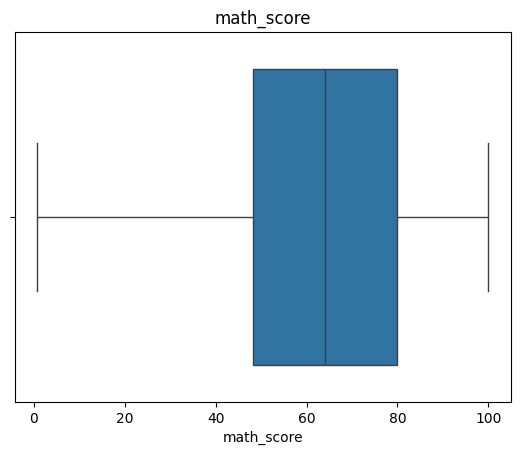

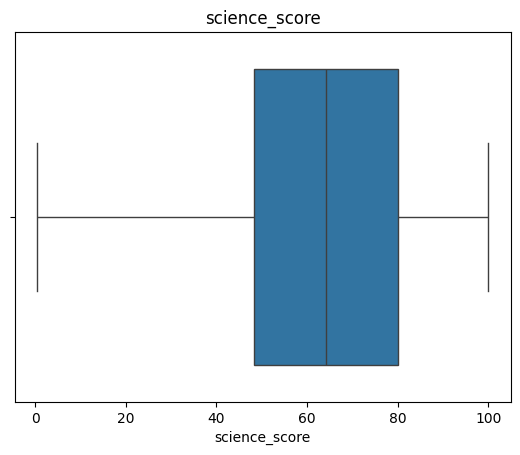

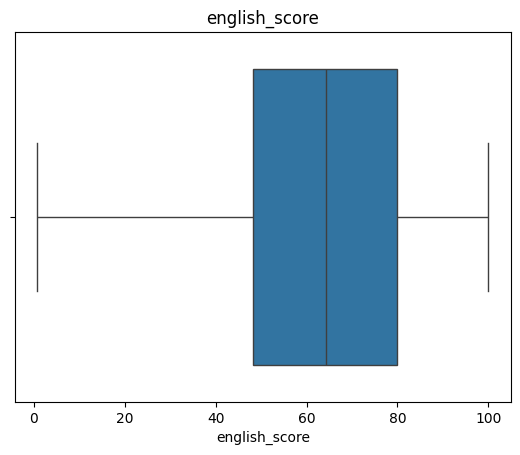

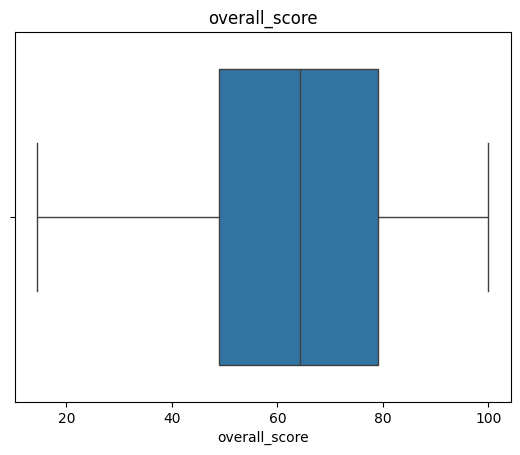

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
df["final_grade"].value_counts()

,count
final_grade,
d,6311
c,6161
e,5672
f,2955
b,2696
a,1205


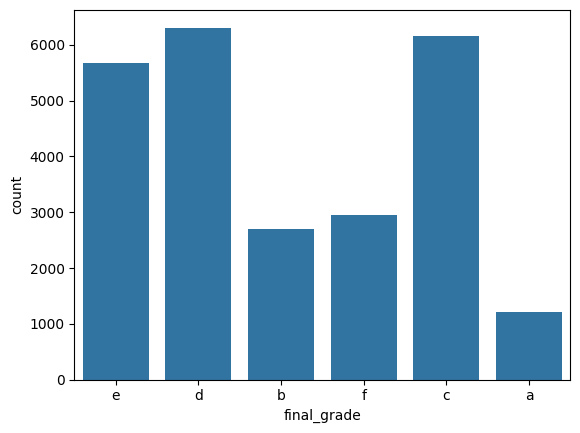

In [ ]:
sns.countplot(x=df["final_grade"])
plt.show()

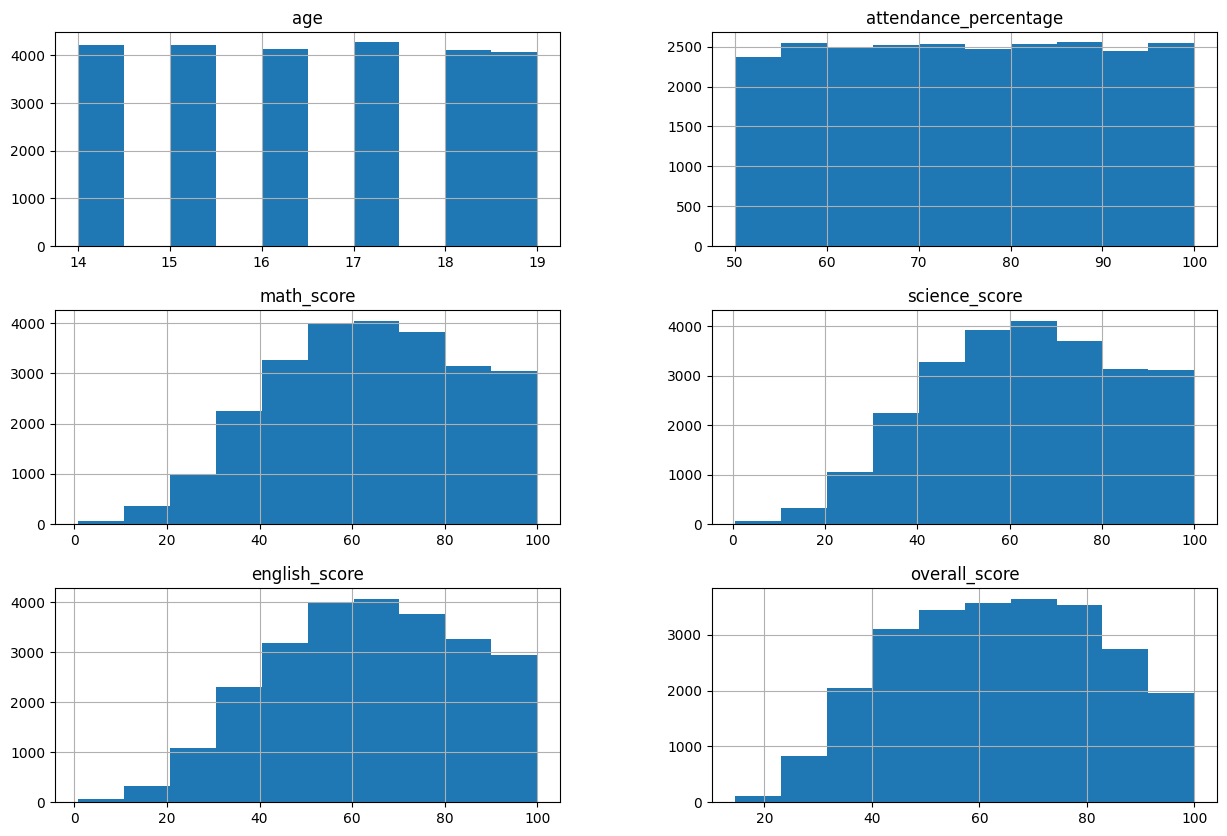

In [ ]:
df.hist(figsize=(15,10))
plt.show()

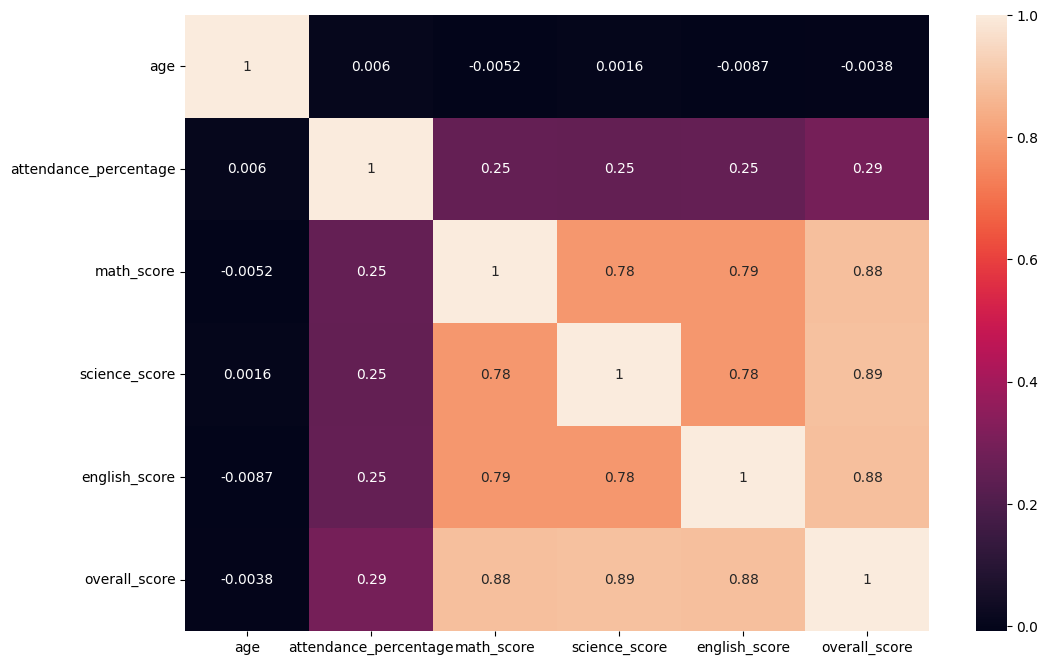

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
X = df.drop("final_grade", axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True) # drop_first to avoid multicollinearity

y = df["final_grade"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.model_selection import train_test_split

# Re-split the data to ensure X_train and X_test reflect the one-hot encoded X
# This is necessary because X_train and X_test in the current kernel state
# do not reflect the one-hot encoding applied to X in a previous step.
X_train, X_test, y_train, y_test = train_test_split(
    X, # Use the already one-hot encoded X
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_dt)

0.9982

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           a       1.00      1.00      1.00       241
           b       1.00      1.00      1.00       539
           c       1.00      1.00      1.00      1232
           d       1.00      1.00      1.00      1262
           e       1.00      1.00      1.00      1135
           f       1.00      1.00      1.00       591

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

[[ 240    1    0    0    0    0]
 [   0  538    1    0    0    0]
 [   0    0 1230    2    0    0]
 [   0    0    0 1259    3    0]
 [   0    0    0    0 1133    2]
 [   0    0    0    0    0  591]]


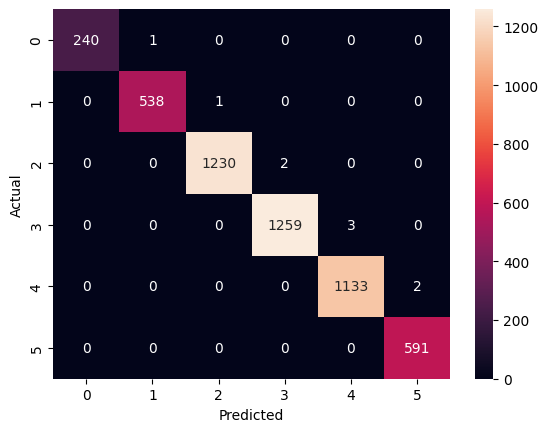

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
5,overall_score,0.998716
3,science_score,0.000957
23,study_method_textbook,0.000203
9,parent_education_graduate,0.000125
2,math_score,0.000000
4,english_score,0.000000
1,attendance_percentage,0.000000
0,age,0.000000
7,gender_other,0.000000
6,gender_male,0.000000


In [ ]:
train_acc = dt.score(X_train, y_train)

test_acc = dt.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.99855
Testing Accuracy: 0.9982


In [ ]:
dt.get_depth()

5

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    dt,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.9966 0.9968 0.997  0.9982 0.9978]
0.9972799999999999


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit LabelEncoder on the full target variable to ensure all classes are known
# and transform y_test
y_test_encoded = le.fit_transform(y_test)

# Get probability estimates from the Decision Tree Classifier
y_pred_proba_dt = dt.predict_proba(X_test)

# Calculate roc_auc_score for multiclass classification
# 'ovr' (One-vs-Rest) is a common strategy for multiclass AUC
# 'macro' averages the AUC score for each class, weighted by support
roc_auc_score(y_test_encoded, y_pred_proba_dt, multi_class='ovr', average='macro')

np.float64(0.9999980502446234)

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np # Ensure numpy is imported

# y_test_encoded and y_pred_proba_dt are available from the previous cell.

# Determine the number of classes
num_classes = len(np.unique(y_test_encoded))

# Dictionaries to store FPR, TPR, and AUC for each class
fpr = dict()
tpr = dict()
thresholds = dict()
roc_auc = dict()

for i in range(num_classes):
    # For each class, convert the true labels to a binary format (1 if it's the current class, 0 otherwise)
    # and use the corresponding column from the predicted probabilities.
    fpr[i], tpr[i], thresholds[i] = roc_curve((y_test_encoded == i), y_pred_proba_dt[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Now, fpr[i], tpr[i], thresholds[i], and roc_auc[i] contain the ROC curve data for each class i.
# These can be used to plot individual ROC curves or derive aggregated curves (e.g., macro/micro average).

In [ ]:
import numpy as np

# The roc_auc dictionary from the previous cell already contains the AUC scores for each class.

print("ROC AUC Scores per Class:")
for class_idx, score in roc_auc.items():
    print(f"  Class {class_idx}: {score:.6f}")

# Calculate the macro average ROC AUC score
macro_avg_roc_auc = np.mean(list(roc_auc.values()))
print(f"\nMacro Average ROC AUC Score: {macro_avg_roc_auc:.6f}")


ROC AUC Scores per Class:
  Class 0: 0.999999
  Class 1: 0.999998
  Class 2: 0.999997
  Class 3: 0.999997
  Class 4: 0.999998
  Class 5: 1.000000

Macro Average ROC AUC Score: 0.999998


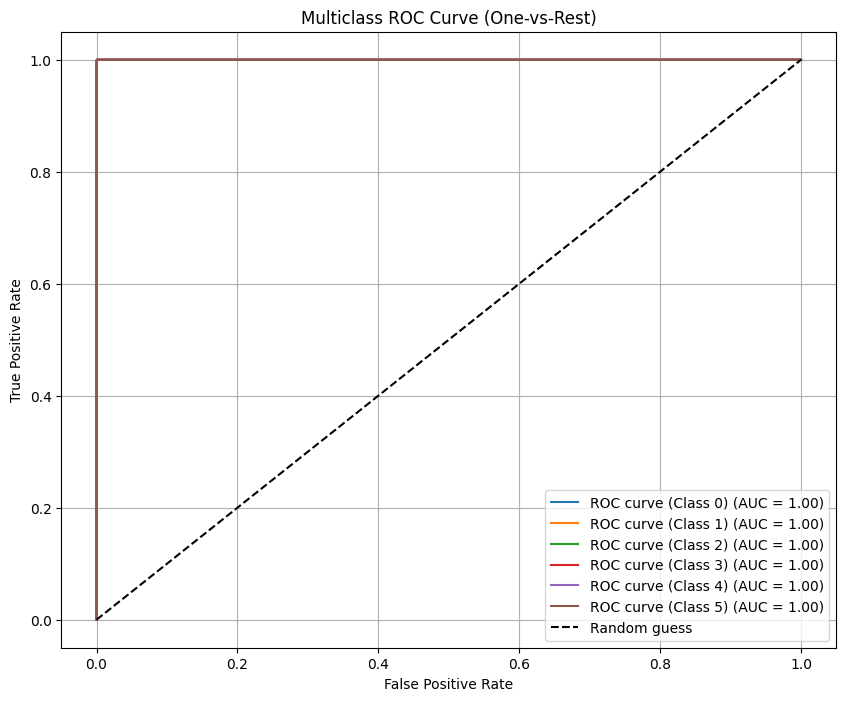

In [ ]:
plt.figure(figsize=(10, 8))

# Plot ROC curve for each class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve (Class {i}) (AUC = {roc_auc[i]:.2f})')

# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Randam forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_rf)

0.9918

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           a       1.00      0.90      0.95       241
           b       0.95      0.99      0.97       539
           c       1.00      1.00      1.00      1232
           d       1.00      1.00      1.00      1262
           e       0.99      1.00      1.00      1135
           f       1.00      0.99      0.99       591

    accuracy                           0.99      5000
   macro avg       0.99      0.98      0.98      5000
weighted avg       0.99      0.99      0.99      5000



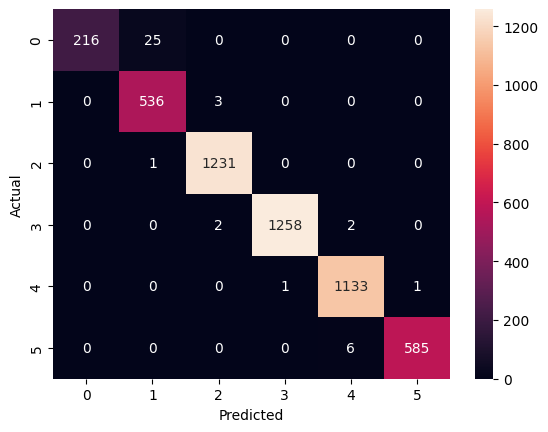

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
5,overall_score,0.583614
2,math_score,0.139202
3,science_score,0.128984
4,english_score,0.115931
1,attendance_percentage,0.015758
0,age,0.002688
14,internet_access_yes,0.001027
18,extra_activities_yes,0.000946
8,school_type_public,0.000901
6,gender_male,0.000882


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.9938 0.9936 0.9902 0.9946 0.9978]
0.994


In [ ]:
from sklearn.metrics import roc_auc_score

# Get probability estimates from the RandomForestClassifier
y_pred_proba_rf = rf.predict_proba(X_test)

# Calculate roc_auc_score for multiclass classification
# y_test_encoded contains the numerical labels for y_test
# 'ovr' (One-vs-Rest) is a common strategy for multiclass AUC
# 'macro' averages the AUC score for each class, weighted equally
roc_auc_score(y_test_encoded, y_pred_proba_rf, multi_class='ovr', average='macro')

np.float64(0.9999576051312863)

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# y_test_encoded and y_pred_proba_rf are available from previous steps.

# Determine the number of classes (from y_test_encoded)
num_classes_rf = len(np.unique(y_test_encoded))

# Dictionaries to store FPR, TPR, and AUC for each class for Random Forest
fpr_rf = dict()
tpr_rf = dict()
thresholds_rf = dict()
roc_auc_rf = dict()

for i in range(num_classes_rf):
    # For each class, convert the true labels to a binary format (1 if it's the current class, 0 otherwise)
    # and use the corresponding column from the predicted probabilities for the Random Forest model.
    fpr_rf[i], tpr_rf[i], thresholds_rf[i] = roc_curve((y_test_encoded == i), y_pred_proba_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

# Now, fpr_rf[i], tpr_rf[i], thresholds_rf[i], and roc_auc_rf[i] contain the ROC curve data for each class i.
# These can be used to plot individual ROC curves or derive aggregated curves (e.g., macro/micro average).

In [ ]:
import numpy as np

# The roc_auc_rf dictionary from the previous cell already contains the AUC scores for each class for the Random Forest model.

print("Random Forest ROC AUC Scores per Class:")
for class_idx, score in roc_auc_rf.items():
    print(f"  Class {class_idx}: {score:.6f}")

# Calculate the macro average ROC AUC score for Random Forest
macro_avg_roc_auc_rf = np.mean(list(roc_auc_rf.values()))
print(f"\nRandom Forest Macro Average ROC AUC Score: {macro_avg_roc_auc_rf:.6f}")

Random Forest ROC AUC Scores per Class:
  Class 0: 0.999907
  Class 1: 0.999906
  Class 2: 0.999999
  Class 3: 0.999999
  Class 4: 0.999974
  Class 5: 0.999961

Random Forest Macro Average ROC AUC Score: 0.999958


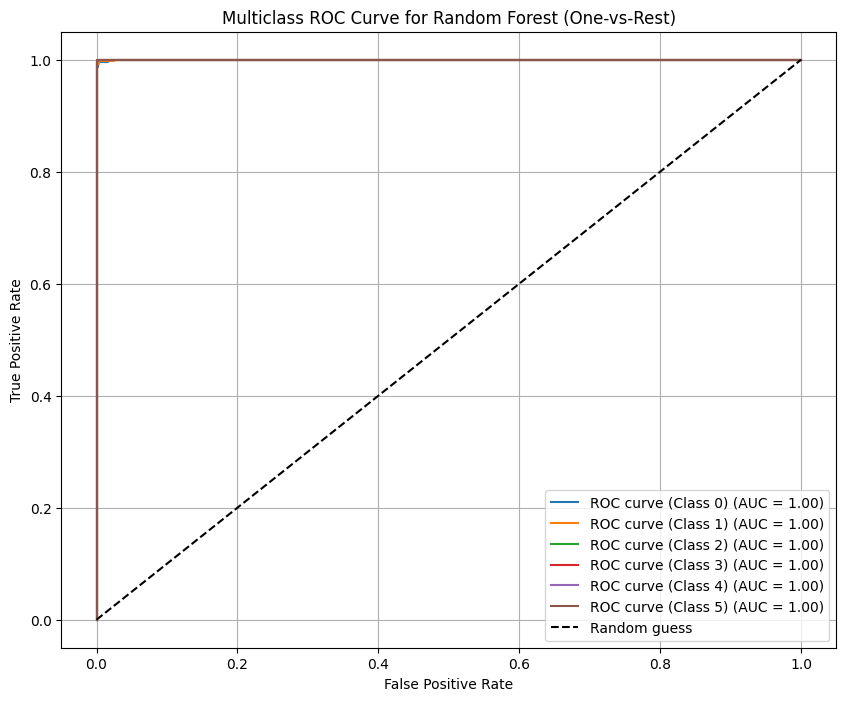

In [ ]:
plt.figure(figsize=(10, 8))

# Plot ROC curve for each class for Random Forest
for i in range(num_classes_rf):
    plt.plot(fpr_rf[i], tpr_rf[i], label=f'ROC curve (Class {i}) (AUC = {roc_auc_rf[i]:.2f})')

# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve for Random Forest (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()